# Nonstationarity Index - Spacial and Temporal 

Two Nonstationairty Indices were used for quantification, a Spacial Non-Stationarity Index $NSI_{sp}$ and a Temporal Non-Stationarity Index. Both indices were used for quality check, at the beginning of the calculations on the data used for the purpose of this work.THe spaital index measures slow drifts in CoM raw displacement time series along each axis separately by comparing the variability of window-means to the overall signal variability. The default window lenght is around 5s according to the literature (Riva et al. (2014)), which also follows this paper. Elevated spatial index flags directional drifts in CoM position, as for example a gradual lateral sway (ML axis)that violates stationarity and can introduce a bias nonlinear metrics. The data is preprocessed the same way, the data is preprocessed before the nonlinear coefficient calculations.

## Preprocessing

THe preprocessing is done in few steps: 
- First, from the channel dimension in the markers NetCDF, the previously calculated Center of Mass raw time displacement data is extracted. Then, the dataarray is transponsed such that tiem becomes the first dimension and axis the second. This transforms com in a NumPy array with 3 dimensions, when extracting the values. The 3 dimensions correspond to the three walking axes, Mediolaternal (x), Antiposterior (y) and Vertical (z)

- Second, the signal in each axis is prone to highpass filterings with a cutoff frequency of 0.1 Hz on 100 Hz sampling. The highpass filter remove very slow drifts below the applied quantity. The highpass filtering uses the Butterworth method of 4th order. Next, a zero-phase filtering is applied such that the phase of higher frequency components (in case of perturbations) is preserved. This effectively detrends each axis by removing baseline noise and very slow positional drift.

- Third, the signals are zero centered - the first sample is extracted from each fitlered axis. This way all signals start from 0.


The data is only preprocessed for the computation of spatial nonstationary index. 

FOr the temporal nonstaionaity index, the events table is only needed not the signal plots, because it calucates the regularity of the strides and steps.

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, filtfilt
from typing import Union

def _butter_filter(ts, fs, hp_cutoff=None, lp_cutoff=None, order=4):
    """High/low/band pass filter, same as before."""
    nyq = 0.5 * fs
    if hp_cutoff is None and lp_cutoff is None:
        return ts

    if hp_cutoff and lp_cutoff:
        btype = 'band'
        freqs = [hp_cutoff/nyq, lp_cutoff/nyq]
    elif hp_cutoff:
        btype = 'high'; freqs = hp_cutoff/nyq
    else:
        btype = 'low';  freqs = lp_cutoff/nyq

    b, a = butter(order, freqs, btype=btype)
    return filtfilt(b, a, ts)

# 1) Preprocessing: detrend, band‐pass, and z‐score
def preprocess_signal(data: Union[xr.DataArray, np.ndarray],
                      fs: float,
                      poly_order: int = 1,
                      hp_cutoff: float = None,
                      lp_cutoff: float = None,
                      filter_order: int = 4) -> np.ndarray:
    """
    Globally filter and detrend the data, then return as numpy array.
    Handles both xarray DataArrays and 1D numpy arrays.
    """
    # Handle 1D numpy array input
    if isinstance(data, np.ndarray):
        if data.ndim != 1:
            raise ValueError("Numpy array input must be 1D")
        
        ts = data.astype(float)
        N = len(ts)
        tidx = np.arange(N)
        
        # Filter
        tsf = _butter_filter(ts, fs, hp_cutoff, lp_cutoff, filter_order)
        
        # Detrend
        coeffs = np.polyfit(tidx, tsf, poly_order)
        return tsf - np.polyval(coeffs, tidx)
    
    # Handle xarray DataArray (original code)
    axes = data.coords['axis'].values
    chans = data.coords['channel'].values
    full = data.copy(deep=True).astype(float)
    N = full.sizes['time']
    tidx = np.arange(N)
    
    for ax in axes:
        for ch in chans:
            ts = full.sel(axis=ax, channel=ch).values
            tsf = _butter_filter(ts, fs, hp_cutoff, lp_cutoff, filter_order)
            coeffs = np.polyfit(tidx, tsf, poly_order)
            full.loc[dict(axis=ax, channel=ch)] = tsf - np.polyval(coeffs, tidx)
    
    return full.values

def compute_spatial_nsi(markers: xr.DataArray,
                        window_samples: int = 500,
                        fs: float = 100.0) -> dict:
    """
    
     1) Extract 'COM' channel, transpose to dims ('time','axis')
     2) Detrend all axes (x, y, z) with a 0.1 Hz high-pass filter
     3) Anchor each filtered axis so it starts at zero
     4) Compute NSI separately for x, y, z using non-overlapping windows of size `window_samples`

    Parameters
    ----------
    markers : xr.DataArray
        DataArray with dims ('axis','channel','time') and a channel named 'COM'.
    window_samples : int
        Number of time-samples in each non-overlapping window for NSI.
    fs : float
        Sampling rate (Hz) of the COM time series.

    Returns
    -------
    tuple
        - dict: Spatial NSI for each axis: {'x': val, 'y': val, 'z': val}
        - dict: Detailed window results for each axis with (window_range, mean, std) for each window
    """
    
    com = markers.sel(channel='COM').transpose('time', 'axis')
    data = com.values.copy()  

    com_dt = xr.DataArray(data, coords=com.coords, dims=com.dims)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axis_names = ['x', 'y', 'z']
    axis_labels = ['ML (x)', 'AP (y)', 'VT (z)']
    
    for idx, (ax_name, ax_label) in enumerate(zip(axis_names, axis_labels)):
        if ax_name in com_dt.axis.values:
            axes[idx].plot(com_dt.sel(axis=ax_name).values, label=f"Filtered {ax_label}")
            axes[idx].set_ylabel(f"{ax_label} Position\n(detrended)")
            axes[idx].legend()
            axes[idx].grid(True)
    
    axes[0].set_title("High-Pass Filtered COM Traces (All Axes)")
    axes[-1].set_xlabel("Sample")
    plt.tight_layout()
    plt.show()

 
    def nsi_detailed(ts: np.ndarray, w: int) -> tuple:
        n = len(ts)
        if n < w:
            return np.nan, []
        
        windows = []
        window_means = []
        window_stds = []
        
        for i in range(0, n - w + 1, w):
            window_data = ts[i:i+w]
            windows.append((i, i+w))
            window_means.append(np.mean(window_data))
            window_stds.append(np.std(window_data, ddof=1))
        
    
        overall_std = np.std(ts, ddof=1)
        if overall_std == 0:
            return np.nan, []
        
        nsi_value = np.std(window_means, ddof=1) / overall_std
        
        return nsi_value, list(zip(windows, window_means, window_stds))

    N = com_dt.sizes['time']
    M = (N - window_samples) // window_samples + 1
    print(f"COM series length: {N} samples ({N/fs:.2f} s)")
    print(f"Window size:       {window_samples} samples ({window_samples/fs:.2f} s)")
    print(f"Number of windows: {M}")
    print("-" * 80)

    results = {}
    detailed_results = {}
    
    for ax in com_dt.axis.values:
        arr = com_dt.sel(axis=ax).values
        nsi_val, window_details = nsi_detailed(arr, window_samples)
        results[ax] = nsi_val
        detailed_results[ax] = window_details

        print(f"\nAxis: {ax}")
        print(f"Overall NSI: {nsi_val:.4f}")
        print(f"{'Window':<15} {'Time Range (s)':<20} {'Mean':<12} {'Std':<12}")
        print("-" * 60)
        
        for idx, ((start, end), mean, std) in enumerate(window_details):
            time_start = start / fs
            time_end = end / fs
            print(f"Window {idx+1:<8} {time_start:6.2f} - {time_end:6.2f} s    {mean:8.4f}    {std:8.4f}")
   
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    axis_names = ['x', 'y', 'z']
    axis_labels = ['ML (x)', 'AP (y)', 'VT (z)']
    colors = ['blue', 'green', 'red']
    
    for idx, (ax_name, ax_label, color) in enumerate(zip(axis_names, axis_labels, colors)):
        if ax_name in com_dt.axis.values and ax_name in detailed_results:
           
            ax1 = fig.add_subplot(gs[idx, 0])
            time_array = np.arange(len(com_dt.sel(axis=ax_name))) / fs
            ax1.plot(time_array, com_dt.sel(axis=ax_name).values, 'k-', alpha=0.5, linewidth=0.5)
            
            window_data = detailed_results[ax_name]
            for win_idx, ((start, end), mean, std) in enumerate(window_data):
                t_start = start / fs
                t_end = end / fs
             
                ax1.axvspan(t_start, t_end, alpha=0.2, color=color if win_idx % 2 == 0 else 'gray')
           
                ax1.hlines(mean, t_start, t_end, colors=color, linewidth=2)
              
                ax1.text((t_start + t_end) / 2, ax1.get_ylim()[1] * 0.9, f'W{win_idx+1}', 
                        ha='center', va='top', fontsize=8)
            
            ax1.set_ylabel(f'{ax_label} Position')
            ax1.set_title(f'{ax_label} Time Series with Windows')
            ax1.grid(True, alpha=0.3)
            if idx == 2:
                ax1.set_xlabel('Time (s)')
           
            ax2 = fig.add_subplot(gs[idx, 1])
            window_indices = list(range(1, len(window_data) + 1))
            window_means = [w[1] for w in window_data]
            window_stds = [w[2] for w in window_data]
            
            # Plot means with error bars (std)
            ax2.errorbar(window_indices, window_means, yerr=window_stds, 
                        fmt='o-', color=color, capsize=5, capthick=2,
                        label='Mean ± Std')
            ax2.axhline(y=np.mean(window_means), color='black', linestyle='--', 
                       alpha=0.5, label='Overall mean')
            
            ax2.set_ylabel('Value')
            ax2.set_title(f'{ax_label} Window Statistics')
            ax2.grid(True, alpha=0.3)
            ax2.legend()
            if idx == 2:
                ax2.set_xlabel('Window Number')
            
           
            ax3 = fig.add_subplot(gs[idx, 2])
           
            overall_mean = np.mean(com_dt.sel(axis=ax_name).values)
            deviations = [w[1] - overall_mean for w in window_data]
            
            ax3.bar(window_indices, deviations, color=color, alpha=0.7)
            ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
            ax3.set_ylabel('Deviation from Overall Mean')
            ax3.set_title(f'{ax_label} Window Mean Deviations')
            ax3.grid(True, alpha=0.3)
            
            # Add NSI value
            ax3.text(0.98, 0.95, f'NSI = {results.get(ax_name, np.nan):.4f}', 
                    transform=ax3.transAxes, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            if idx == 2:
                ax3.set_xlabel('Window Number')
    
    fig.suptitle(f'NSI Window Analysis (Window size: {window_samples/fs:.1f}s, Total: {N/fs:.1f}s)', 
                 fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Additional summary plot: Window means across all axes
    fig2, ax = plt.subplots(figsize=(12, 6))
    
    for ax_name, color in zip(axis_names, colors):
        if ax_name in detailed_results:
            window_data = detailed_results[ax_name]
            if window_data:
                window_centers = [(w[0][0] + w[0][1]) / 2 / fs for w in window_data]
                window_means = [w[1] for w in window_data]
                
                ax.plot(window_centers, window_means, 'o-', color=color, 
                       label=f'{ax_name.upper()} (NSI={results.get(ax_name, np.nan):.4f})',
                       markersize=8, linewidth=2)
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Window Mean Position')
    ax.set_title('Window Means Comparison Across All Axes')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return results, detailed_results

# def compute_temporal_nsi(events_df, strides_per_window=5,
#                           outlier_thresh=3.0):
    
#     df_fs = events_df.rename(columns={'label':'label','context':'context'})
#     df_fs = df_fs[df_fs['label']=='Foot Strike'].copy()
    
#     # Sort by time to maintain chronological order
#     df_fs = df_fs.sort_values('time')
    
#     # Compute step intervals chronologically (time between consecutive foot strikes)
#     intervals = df_fs['time'].diff().dropna().values
    
#     # Optional: If you want stride intervals (left-to-left or right-to-right only)
#     # Uncomment one of these lines instead of the above:
#     # intervals = df_fs[df_fs['context']=='Left']['time'].diff().dropna().values  # Left stride intervals
#     # intervals = df_fs[df_fs['context']=='Right']['time'].diff().dropna().values  # Right stride intervals
    
#     # Trim initial and final strides if requested
#     if len(intervals) > 2*trim_strides:
#         intervals = intervals[trim_strides:-trim_strides]
    
#     # Remove outliers
#     mu, sigma = intervals.mean(), intervals.std(ddof=1)
#     intervals = intervals[np.abs(intervals-mu) <= outlier_thresh*sigma]
    
#     def nsi(ts, k):
#         n = len(ts)
#         if n < k or ts.std(ddof=1)==0: 
#             return np.nan
#         block_means = [ts[i:i+k].mean() for i in range(0, n-k+1, k)]
#         return np.std(block_means, ddof=1) / ts.std(ddof=1)
    
#     return nsi(intervals, strides_per_window)



def compute_temporal_nsi_from_events(df_events: pd.DataFrame,
                                     strides_per_window: int = 10,
                                     trim_strides: int = 20,
                                     outlier_thresh: float = 3.0) -> float:
    # 1) Filter for Foot Strike and sort chronologically
    df_fs = (df_events[df_events['label'] == 'Foot Strike']
             .sort_values('time'))

    # 2) Compute step intervals
    intervals = df_fs['time'].diff().dropna().values

    # 3) Trim startup/shutdown steps
    if len(intervals) > 2 * trim_strides:
        intervals = intervals[trim_strides:-trim_strides]

    # 4) Outlier rejection
    mu, sigma = intervals.mean(), intervals.std(ddof=1)
    mask = np.abs(intervals - mu) <= outlier_thresh * sigma
    intervals = intervals[mask]

    # 5) Block‐wise NSI
    def nsi(ts, k):
        n = len(ts)
        if n < k or ts.std(ddof=1) == 0:
            return np.nan
        block_means = [ts[i:i+k].mean() for i in range(0, n-k+1, k)]
        return np.std(block_means, ddof=1) / ts.std(ddof=1)

    return nsi(intervals, strides_per_window)


# Patient 03

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Markers DataArray loaded with shape: (3, 125, 24595)
Markers dimensions: ('axis', 'channel', 'time')
Markers coordinates: ['axis', 'channel', 'time']
Events DataFrame loaded with shape: (883, 4)
Events columns: ['time', 'label', 'context', 'icon_id']
Events DataFrame filtered to time range: 30.28 to 119.87
Number of foot strikes: 161
Temporal NSI: 0.26913710745397795


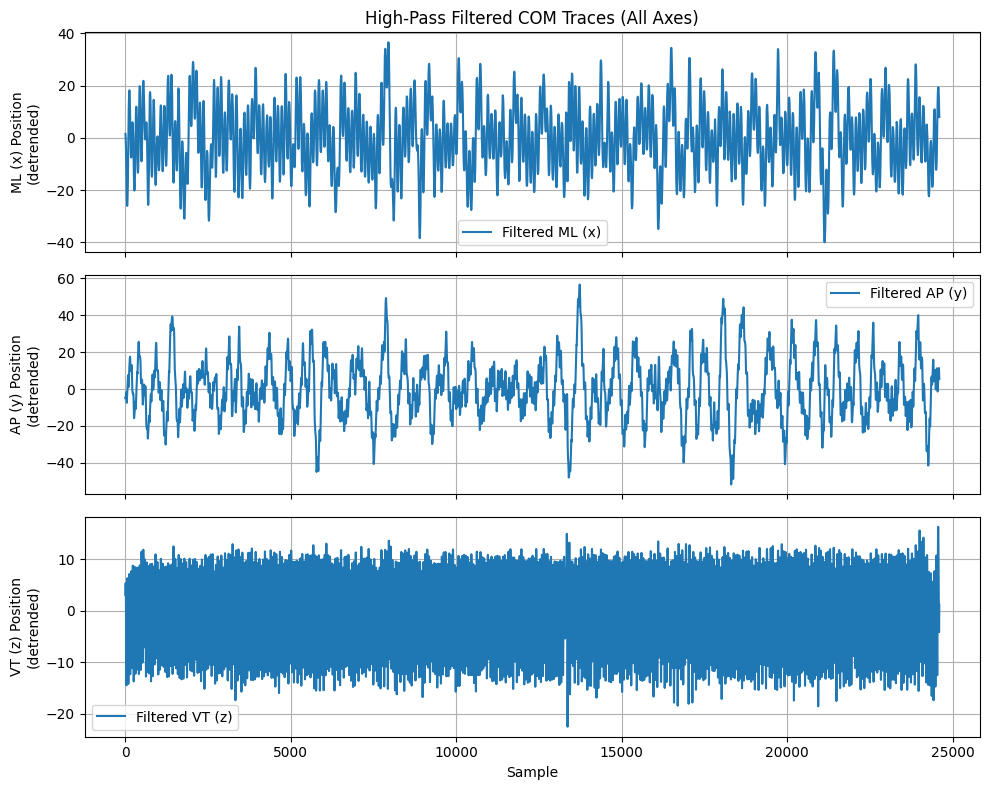

COM series length: 24595 samples (245.95 s)
Window size:       500 samples (5.00 s)
Number of windows: 49
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.2575
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s     -1.8268     12.2117
Window 2          5.00 -  10.00 s     -0.3031     12.1971
Window 3         10.00 -  15.00 s      2.9403     11.7574
Window 4         15.00 -  20.00 s     -4.8086     14.7783
Window 5         20.00 -  25.00 s      3.7935     14.9808
Window 6         25.00 -  30.00 s     -0.8376     14.5381
Window 7         30.00 -  35.00 s      0.7861     12.6029
Window 8         35.00 -  40.00 s      0.9048     13.1058
Window 9         40.00 -  45.00 s     -2.2783     10.3030
Window 10        45.00 -  50.00 s      2.1747     11.0043
Window 11        50.00 -  55.00 s     -1.0329     12.6821
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_9412\290132175.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


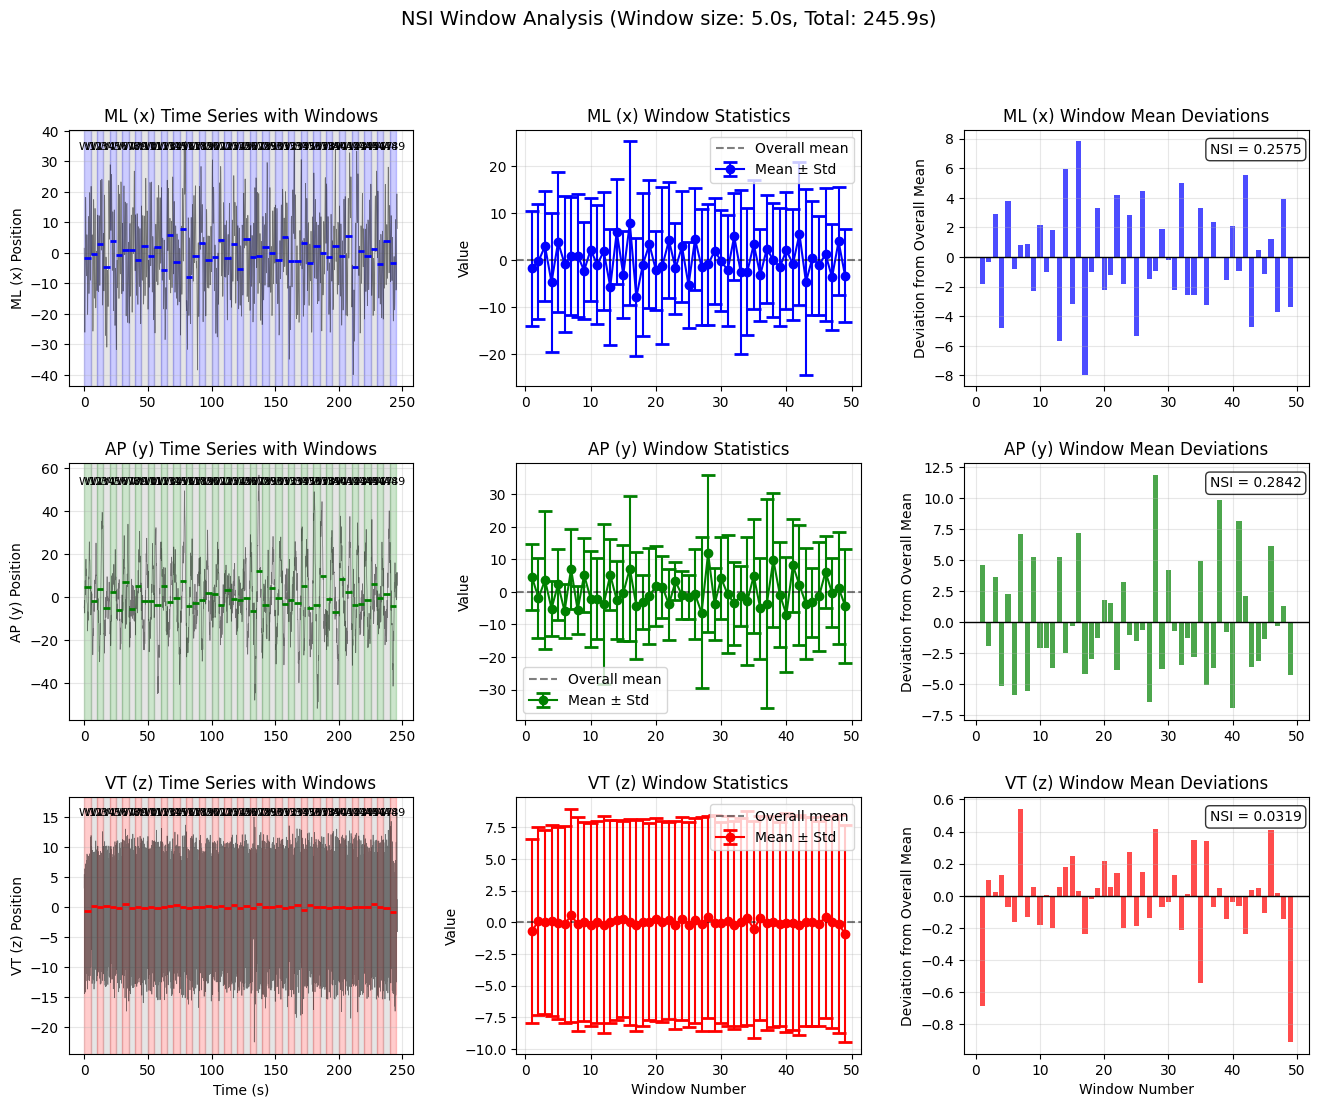

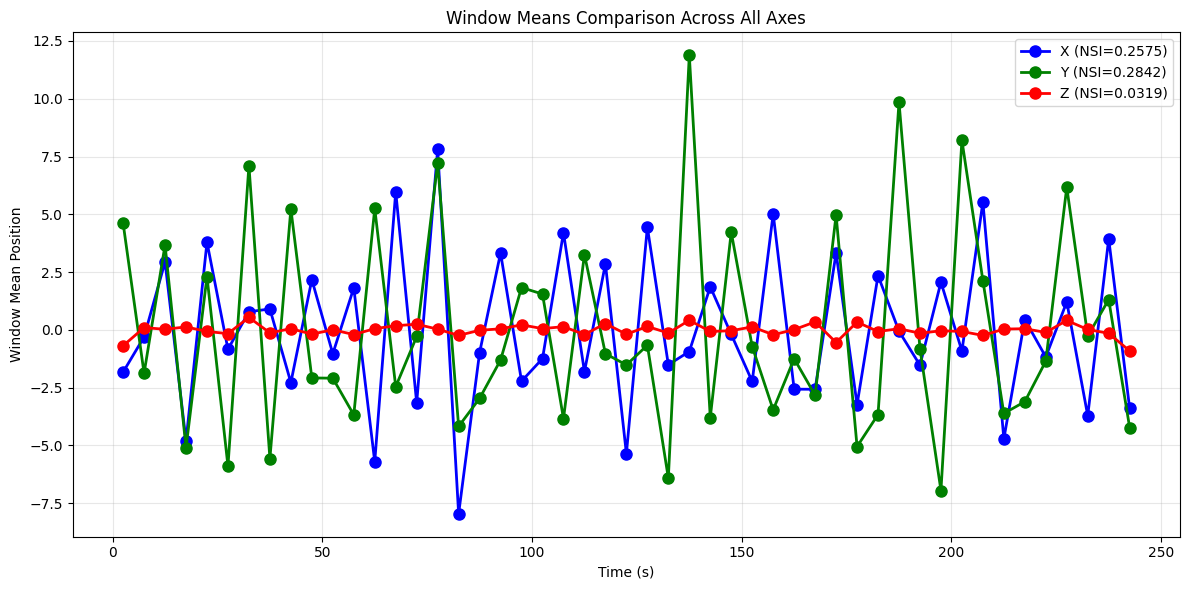

Spatial NSI: {np.str_('x'): np.float64(0.2575199165901658), np.str_('y'): np.float64(0.28419556546202135), np.str_('z'): np.float64(0.03189118665218673)}

SUMMARY
Temporal NSI: 0.2691
Spatial NSI:
  x: 0.2575
  y: 0.2842
  z: 0.0319


In [13]:
import pandas as pd
import xarray as xr
from pathlib import Path

def main():
    # Set up paths
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())
    
    # Fix path - using correct file for markers
    data_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "03" / "markers.nc"
    
    # Fix path - using correct file for events (should be .csv, not .nc)
    events_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "03" / "events.csv"  
    
    try:
        # Load markers data
        ds = xr.open_dataarray(data_path)
        print("Markers DataArray loaded with shape:", ds.shape)
        print("Markers dimensions:", ds.dims)
        print("Markers coordinates:", list(ds.coords.keys()))
        
        # Load events data
        df_events = pd.read_csv(events_path)
        print("Events DataFrame loaded with shape:", df_events.shape)
        print("Events columns:", df_events.columns.tolist())
        
        # Filter events by time range
        t_max = df_events['time'].max()
        trim = 30.0
        df_events_filtered = df_events[(df_events['time'] >= trim) & (df_events['time'] <= 120.0)]
        print(f"Events DataFrame filtered to time range: {df_events_filtered['time'].min():.2f} to {df_events_filtered['time'].max():.2f}")
        
        # Count foot strikes
        foot_strikes = df_events_filtered[df_events_filtered['label'] == 'Foot Strike']
        print("Number of foot strikes:", len(foot_strikes))
        
        # Compute temporal NSI
        nsi_temporal = compute_temporal_nsi_from_events(
            df_events_filtered, 
            strides_per_window=20, 
            trim_strides=20,  # Added missing parameter
            outlier_thresh=3.0
        )
        print("Temporal NSI:", nsi_temporal)
        
        # Preprocess markers data before computing spatial NSI
        # Apply preprocessing to the markers data
        markers_preprocessed = preprocess_signal(
            ds, 
            fs=100.0, 
            poly_order=1, 
            hp_cutoff=0.1,  # High-pass filter at 0.1 Hz as mentioned in spatial NSI function
            lp_cutoff=None,
            filter_order=4
        )
        
        # Convert back to xarray for spatial NSI computation
        ds_preprocessed = xr.DataArray(
            markers_preprocessed,
            coords=ds.coords,
            dims=ds.dims
        )
        
        # Compute spatial NSI
        nsi_spatial, nsi_details = compute_spatial_nsi(
            ds_preprocessed, 
            window_samples=500, 
            fs=100.0
        )
        print("Spatial NSI:", nsi_spatial)
        
        # Print summary
        print("\n" + "="*50)
        print("SUMMARY")
        print("="*50)
        print(f"Temporal NSI: {nsi_temporal:.4f}")
        print("Spatial NSI:")
        for axis, value in nsi_spatial.items():
            print(f"  {axis}: {value:.4f}")
            
    except FileNotFoundError as e:
        print(f"File not found: {e}")
        print("Please check that the file paths are correct.")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

Left column - Time series with windows:

Shows the full filtered signal
Alternating colored shading for each window
Horizontal lines showing each window's mean
Window numbers (W1, W2, etc.) labeled at the top


Middle column - Window statistics:

Window means with error bars (standard deviations)
Dashed line showing the overall mean across all windows
Helps identify which windows have high/low variability


Right column - Window mean deviations:

Bar chart showing how each window's mean deviates from the overall mean
Critical for understanding NSI (NSI measures the variability of these deviations)
NSI value displayed in the corner

# Patient 04

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Markers DataArray loaded with shape: (3, 125, 24480)
Markers dimensions: ('axis', 'channel', 'time')
Markers coordinates: ['axis', 'channel', 'time']
Events DataFrame loaded with shape: (775, 4)
Events columns: ['time', 'label', 'context', 'icon_id']
Events DataFrame filtered to time range: 30.02 to 119.99
Number of foot strikes: 145
Temporal NSI: 0.34229959931069526


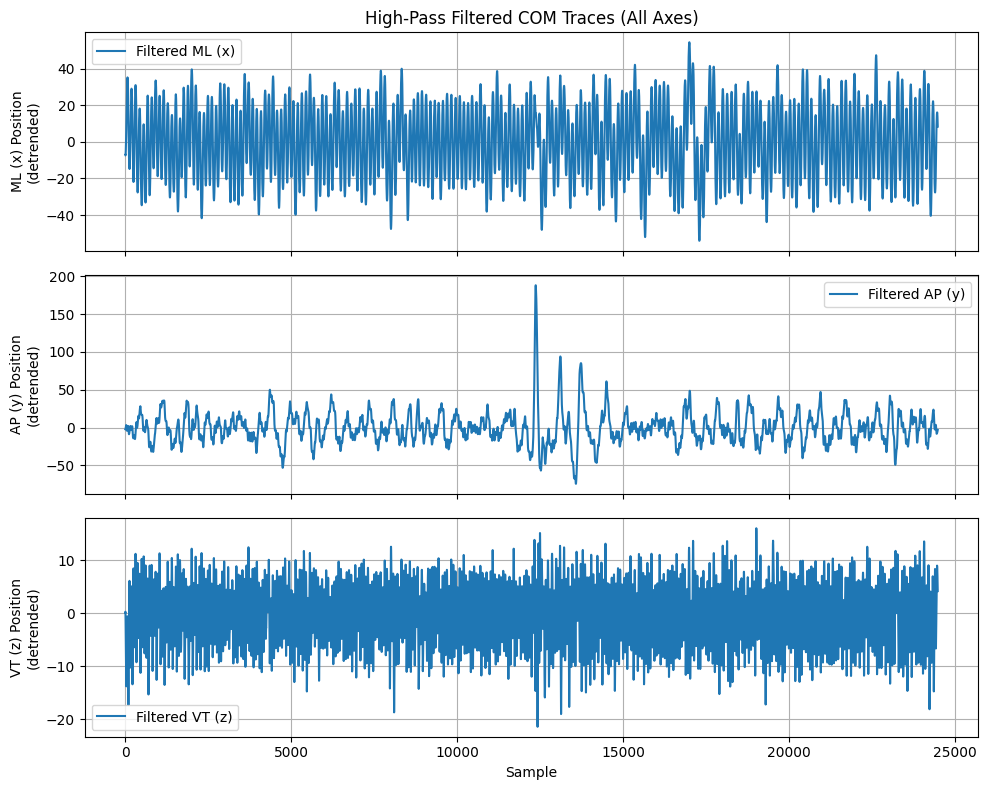

COM series length: 24480 samples (244.80 s)
Window size:       500 samples (5.00 s)
Number of windows: 48
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.1289
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s      3.4270     19.9155
Window 2          5.00 -  10.00 s     -1.2508     19.3102
Window 3         10.00 -  15.00 s     -0.9088     18.0120
Window 4         15.00 -  20.00 s      1.5252     21.0159
Window 5         20.00 -  25.00 s     -1.1140     21.3125
Window 6         25.00 -  30.00 s      1.5778     19.4259
Window 7         30.00 -  35.00 s     -2.9450     19.7165
Window 8         35.00 -  40.00 s      2.3673     20.1731
Window 9         40.00 -  45.00 s      0.6260     21.0556
Window 10        45.00 -  50.00 s     -1.0547     18.5089
Window 11        50.00 -  55.00 s     -2.3244     20.1799
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_9412\290132175.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


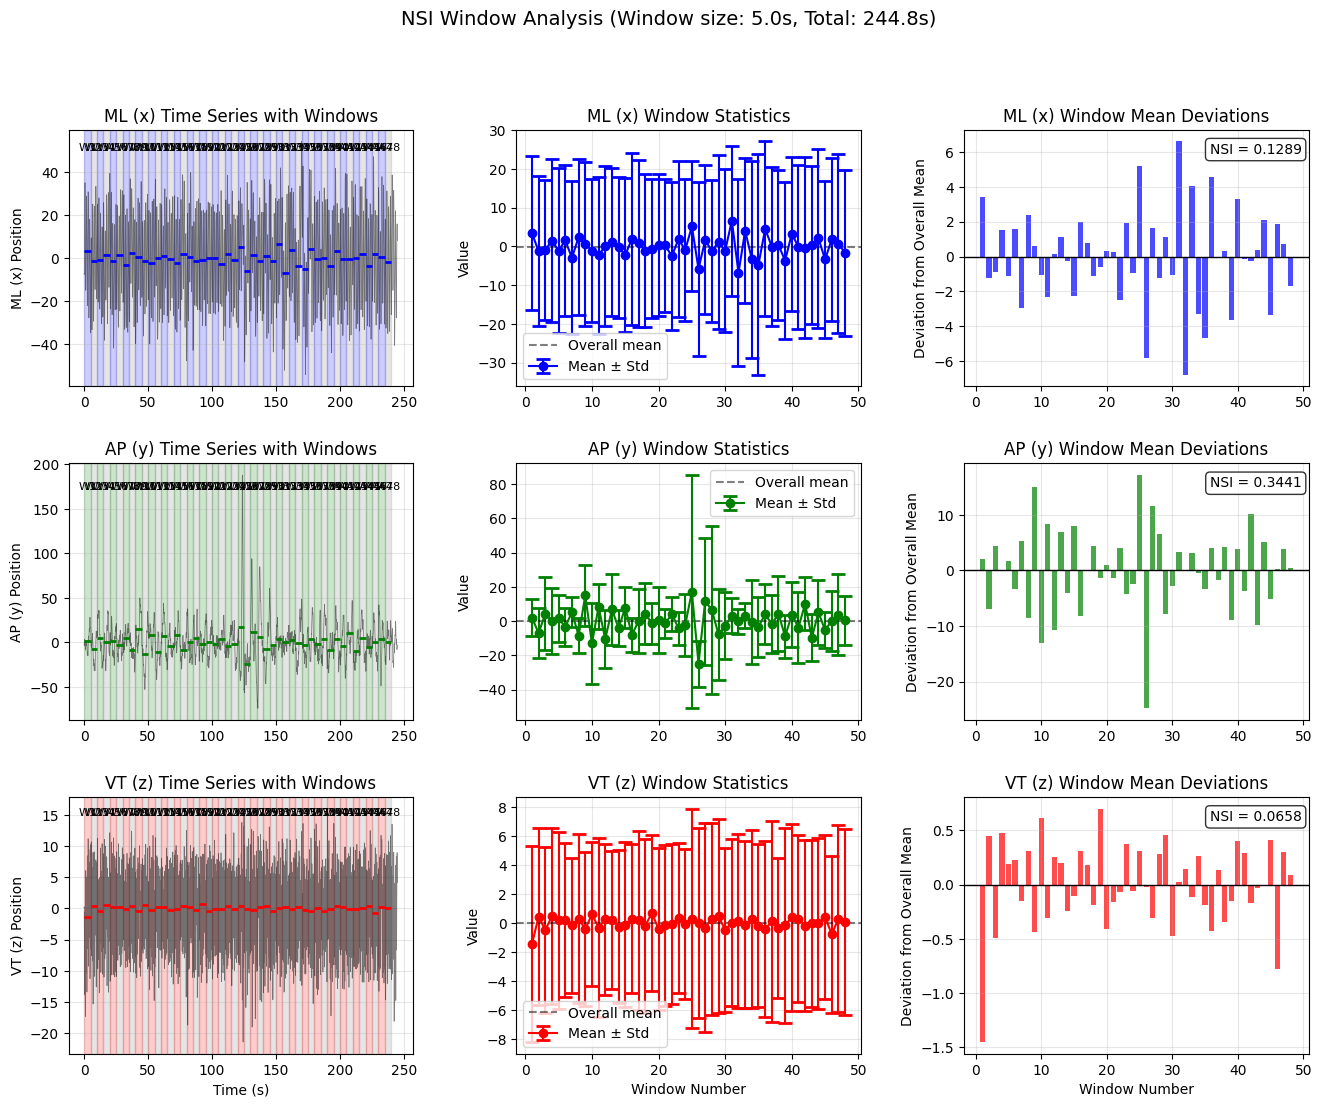

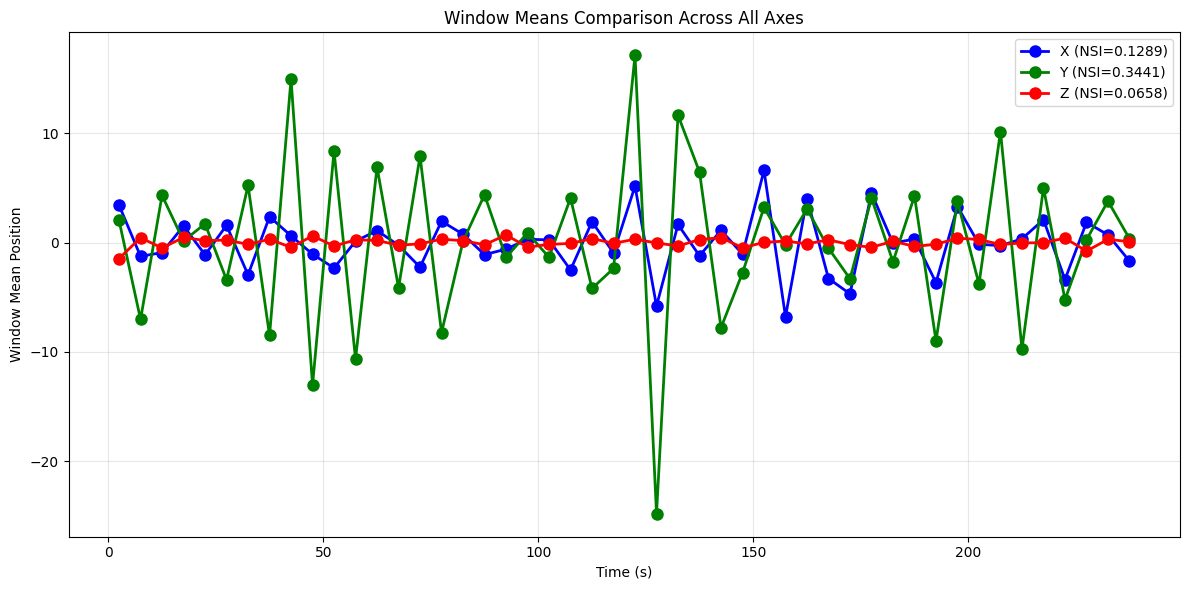

Spatial NSI: {np.str_('x'): np.float64(0.12894048243996312), np.str_('y'): np.float64(0.3441243435872951), np.str_('z'): np.float64(0.0657811914562991)}

SUMMARY
Temporal NSI: 0.3423
Spatial NSI:
  x: 0.1289
  y: 0.3441
  z: 0.0658


In [ ]:
import pandas as pd
import xarray as xr
from pathlib import Path

def main():
    # Set up paths
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())
    
    # Fix path - using correct file for markers
    data_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "04" / "markers.nc"
    
    # Fix path - using correct file for events (should be .csv, not .nc)
    events_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "04" / "events.csv" 
    
    try:
        # Load markers data
        ds = xr.open_dataarray(data_path)
        print("Markers DataArray loaded with shape:", ds.shape)
        print("Markers dimensions:", ds.dims)
        print("Markers coordinates:", list(ds.coords.keys()))
        
        # Load events data
        df_events = pd.read_csv(events_path)
        print("Events DataFrame loaded with shape:", df_events.shape)
        print("Events columns:", df_events.columns.tolist())
        
        # Filter events by time range
        t_max = df_events['time'].max()
        trim = 30.0
        df_events_filtered = df_events[(df_events['time'] >= trim) & (df_events['time'] <= 120.0)]
        print(f"Events DataFrame filtered to time range: {df_events_filtered['time'].min():.2f} to {df_events_filtered['time'].max():.2f}")
        
        # Count foot strikes
        foot_strikes = df_events_filtered[df_events_filtered['label'] == 'Foot Strike']
        print("Number of foot strikes:", len(foot_strikes))
        
        # Compute temporal NSI
        nsi_temporal = compute_temporal_nsi_from_events(
            df_events_filtered, 
            strides_per_window=20, 
            trim_strides=20,  # Added missing parameter
            outlier_thresh=3.0
        )
        print("Temporal NSI:", nsi_temporal)
        
        # Preprocess markers data before computing spatial NSI
        # Apply preprocessing to the markers data
        markers_preprocessed = preprocess_signal(
            ds, 
            fs=100.0, 
            poly_order=1, 
            hp_cutoff=0.1,  # High-pass filter at 0.1 Hz as mentioned in spatial NSI function
            lp_cutoff=None,
            filter_order=4
        )
        
        # Convert back to xarray for spatial NSI computation
        ds_preprocessed = xr.DataArray(
            markers_preprocessed,
            coords=ds.coords,
            dims=ds.dims
        )
        
        # Compute spatial NSI
        nsi_spatial, nsi_details = compute_spatial_nsi(
            ds_preprocessed, 
            window_samples=500, 
            fs=100.0
        )
        print("Spatial NSI:", nsi_spatial)
        
        # Print summary
        print("\n" + "="*50)
        print("SUMMARY")
        print("="*50)
        print(f"Temporal NSI: {nsi_temporal:.4f}")
        print("Spatial NSI:")
        for axis, value in nsi_spatial.items():
            print(f"  {axis}: {value:.4f}")
            
    except FileNotFoundError as e:
        print(f"File not found: {e}")
        print("Please check that the file paths are correct.")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

# Patient 05

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Markers DataArray loaded with shape: (3, 117, 24507)
Markers dimensions: ('axis', 'channel', 'time')
Markers coordinates: ['axis', 'channel', 'time']
Events DataFrame loaded with shape: (891, 4)
Events columns: ['time', 'label', 'context', 'icon_id']
Events DataFrame filtered to time range: 30.15 to 124.66
Number of foot strikes: 173
Temporal NSI: 0.23978156159495304


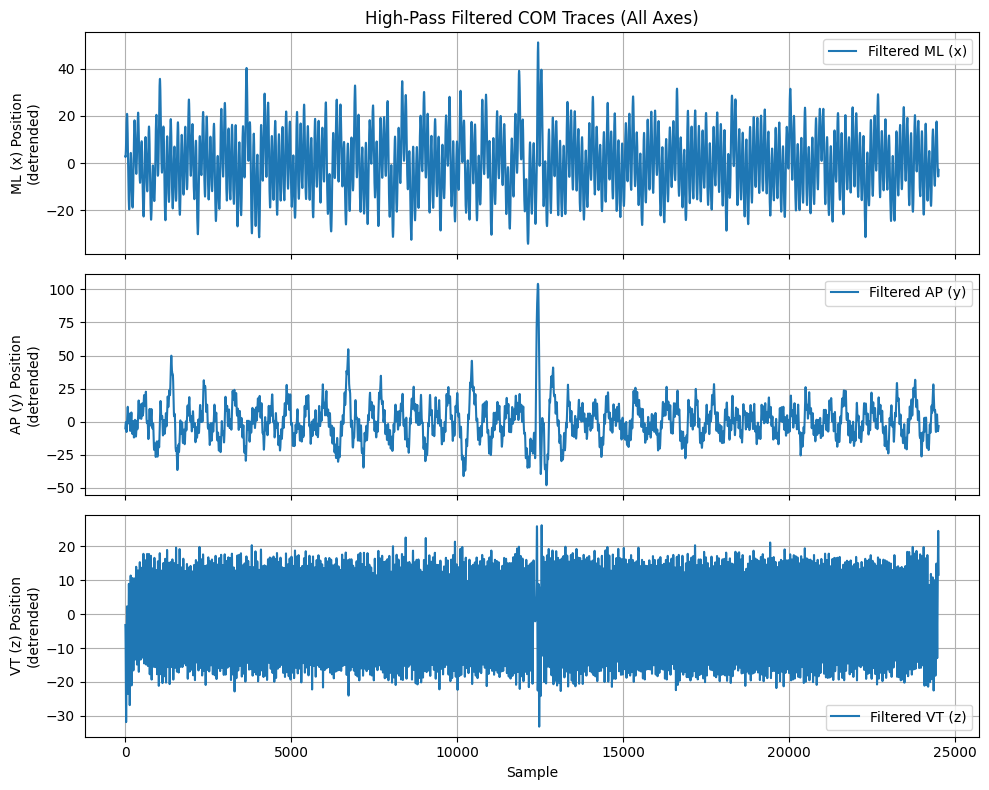

COM series length: 24507 samples (245.07 s)
Window size:       500 samples (5.00 s)
Number of windows: 49
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.1400
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s      2.0274     11.7357
Window 2          5.00 -  10.00 s     -3.6163     11.8544
Window 3         10.00 -  15.00 s      2.1518     14.9171
Window 4         15.00 -  20.00 s      0.5389     12.4318
Window 5         20.00 -  25.00 s      0.1622     13.3828
Window 6         25.00 -  30.00 s     -0.6460     13.1318
Window 7         30.00 -  35.00 s     -2.8234     13.2789
Window 8         35.00 -  40.00 s      1.8037     16.9923
Window 9         40.00 -  45.00 s      0.7914     15.5028
Window 10        45.00 -  50.00 s      0.9929     12.3641
Window 11        50.00 -  55.00 s     -0.5726     13.3791
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_9412\290132175.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


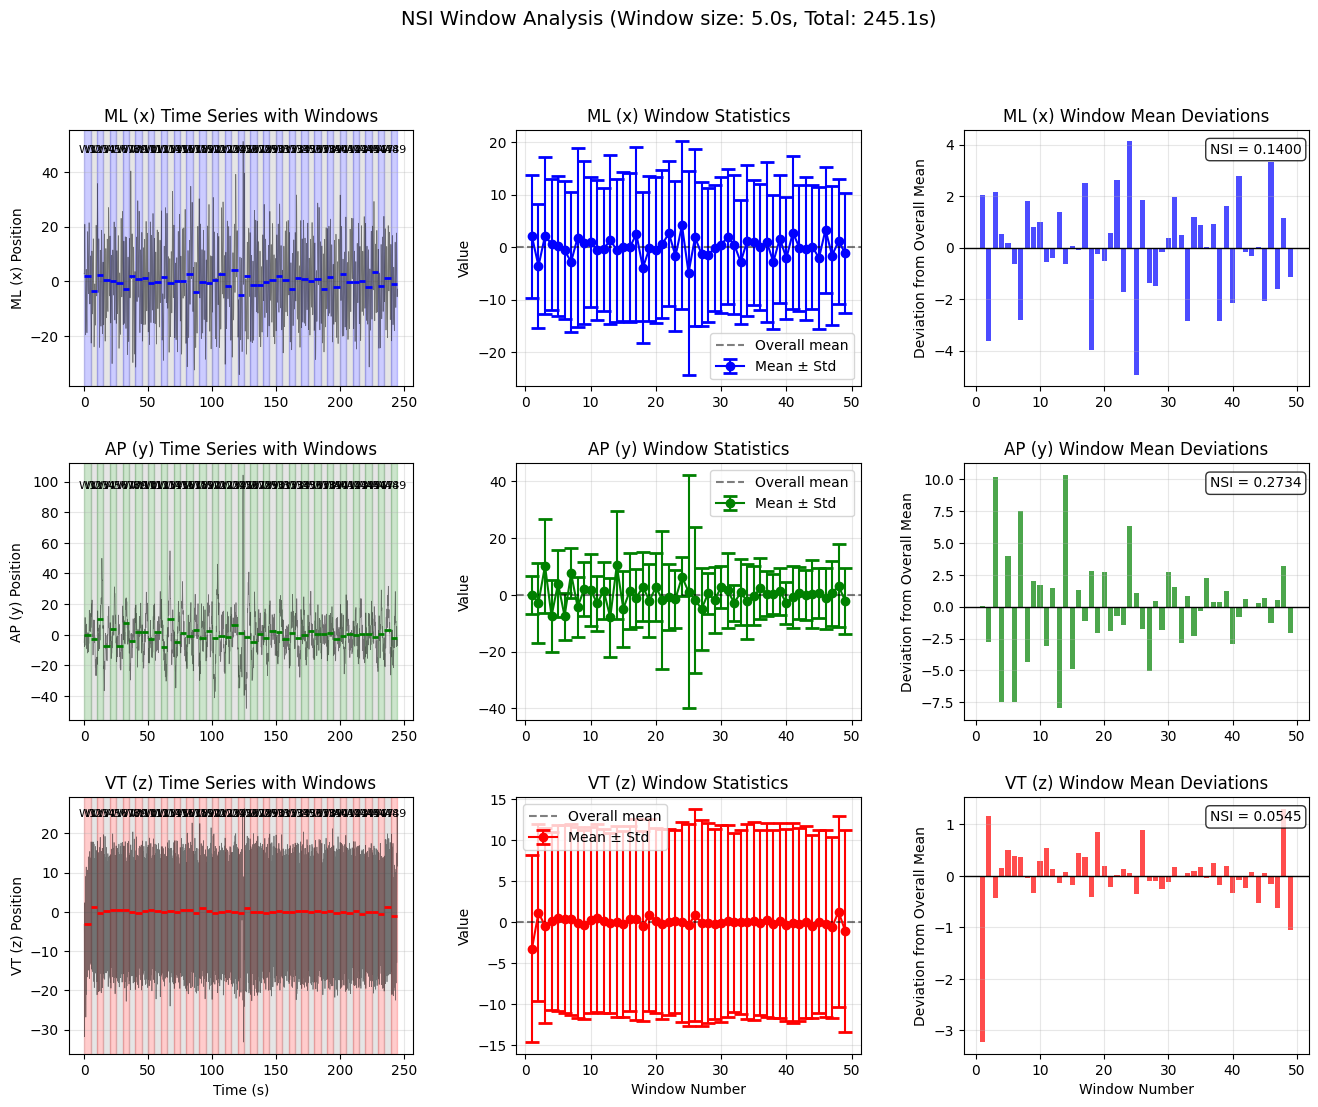

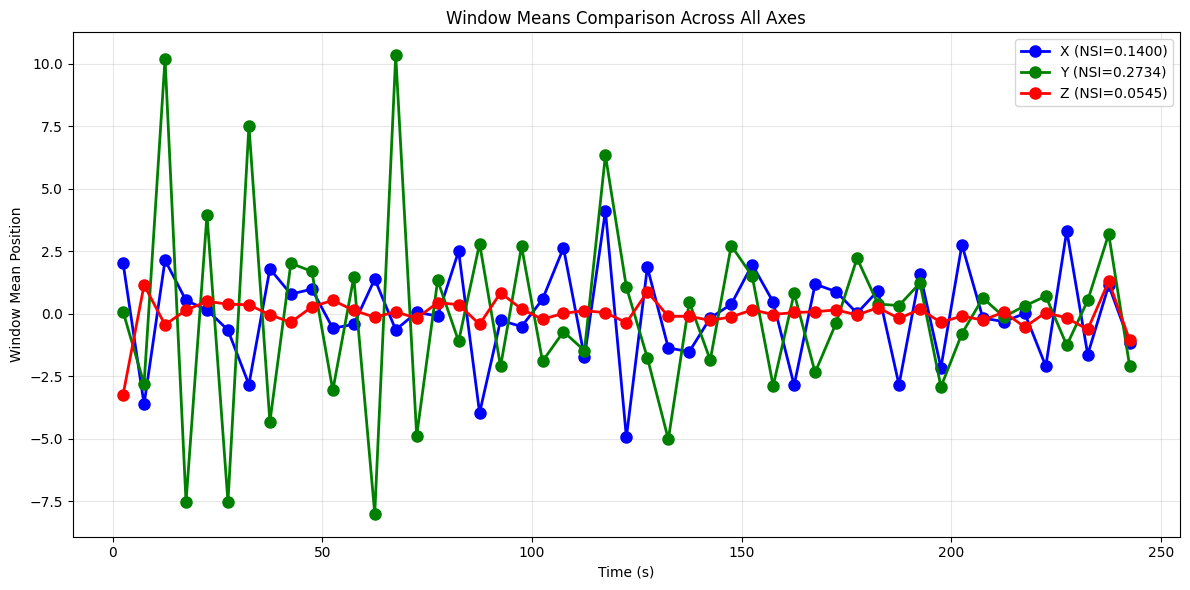

Spatial NSI: {np.str_('x'): np.float64(0.13999453455772437), np.str_('y'): np.float64(0.27343266234089425), np.str_('z'): np.float64(0.05449626997057543)}

SUMMARY
Temporal NSI: 0.2398
Spatial NSI:
  x: 0.1400
  y: 0.2734
  z: 0.0545


In [ ]:
import pandas as pd
import xarray as xr
from pathlib import Path



def main():
    # Set up paths
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())
    
    # Fix path - using correct file for markers
    data_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "05" / "markers.nc"
    
    # Fix path - using correct file for events (should be .csv, not .nc)
    events_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "05" / "events.csv"  # Changed from markers.nc
    
    try:
        # Load markers data
        ds = xr.open_dataarray(data_path)
        print("Markers DataArray loaded with shape:", ds.shape)
        print("Markers dimensions:", ds.dims)
        print("Markers coordinates:", list(ds.coords.keys()))
        
        # Load events data
        df_events = pd.read_csv(events_path)
        print("Events DataFrame loaded with shape:", df_events.shape)
        print("Events columns:", df_events.columns.tolist())
        
        # Filter events by time range
        t_max = df_events['time'].max()
        trim = 30.0
        df_events_filtered = df_events[(df_events['time'] >= trim) & (df_events['time'] <= 125.0)]
        print(f"Events DataFrame filtered to time range: {df_events_filtered['time'].min():.2f} to {df_events_filtered['time'].max():.2f}")
        
        # Count foot strikes
        foot_strikes = df_events_filtered[df_events_filtered['label'] == 'Foot Strike']
        print("Number of foot strikes:", len(foot_strikes))
        
        # Compute temporal NSI
        nsi_temporal = compute_temporal_nsi_from_events(
            df_events_filtered, 
            strides_per_window=20, 
            trim_strides=20,  # Added missing parameter
            outlier_thresh=3.0
        )
        print("Temporal NSI:", nsi_temporal)
        
        # Preprocess markers data before computing spatial NSI
        # Apply preprocessing to the markers data
        markers_preprocessed = preprocess_signal(
            ds, 
            fs=100.0, 
            poly_order=1, 
            hp_cutoff=0.1,  # High-pass filter at 0.1 Hz as mentioned in spatial NSI function
            lp_cutoff=None,
            filter_order=4
        )
        
        # Convert back to xarray for spatial NSI computation
        ds_preprocessed = xr.DataArray(
            markers_preprocessed,
            coords=ds.coords,
            dims=ds.dims
        )
        
        # Compute spatial NSI
        nsi_spatial, nsi_details = compute_spatial_nsi(
            ds_preprocessed, 
            window_samples=500, 
            fs=100.0
        )
        print("Spatial NSI:", nsi_spatial)
        
        # Print summary
        print("\n" + "="*50)
        print("SUMMARY")
        print("="*50)
        print(f"Temporal NSI: {nsi_temporal:.4f}")
        print("Spatial NSI:")
        for axis, value in nsi_spatial.items():
            print(f"  {axis}: {value:.4f}")
            
    except FileNotFoundError as e:
        print(f"File not found: {e}")
        print("Please check that the file paths are correct.")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

# Patient 08

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Markers DataArray loaded with shape: (3, 117, 31579)
Markers dimensions: ('axis', 'channel', 'time')
Markers coordinates: ['axis', 'channel', 'time']
Events DataFrame loaded with shape: (1195, 4)
Events columns: ['time', 'label', 'context', 'icon_id']
Events DataFrame filtered to time range: 30.09 to 124.67
Number of foot strikes: 188
Temporal NSI: 0.3270664641198372


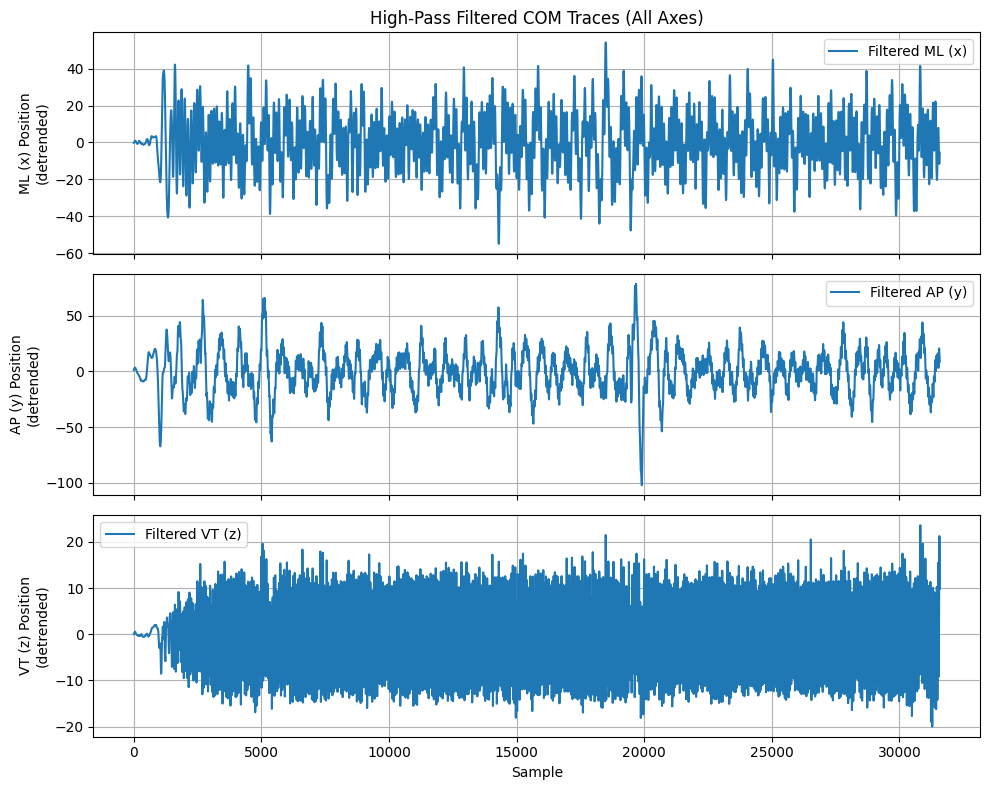

COM series length: 31579 samples (315.79 s)
Window size:       500 samples (5.00 s)
Number of windows: 63
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.1864
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s     -0.2481      0.6664
Window 2          5.00 -  10.00 s     -0.3392      5.0896
Window 3         10.00 -  15.00 s     -0.9774     25.8811
Window 4         15.00 -  20.00 s      3.6566     19.8610
Window 5         20.00 -  25.00 s     -2.8236     18.1107
Window 6         25.00 -  30.00 s     -0.9313     16.8823
Window 7         30.00 -  35.00 s      2.0156     11.3870
Window 8         35.00 -  40.00 s      2.8352     15.4918
Window 9         40.00 -  45.00 s     -4.5340     17.1236
Window 10        45.00 -  50.00 s     -0.8576     16.4657
Window 11        50.00 -  55.00 s      1.2799     17.2628
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_9412\290132175.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


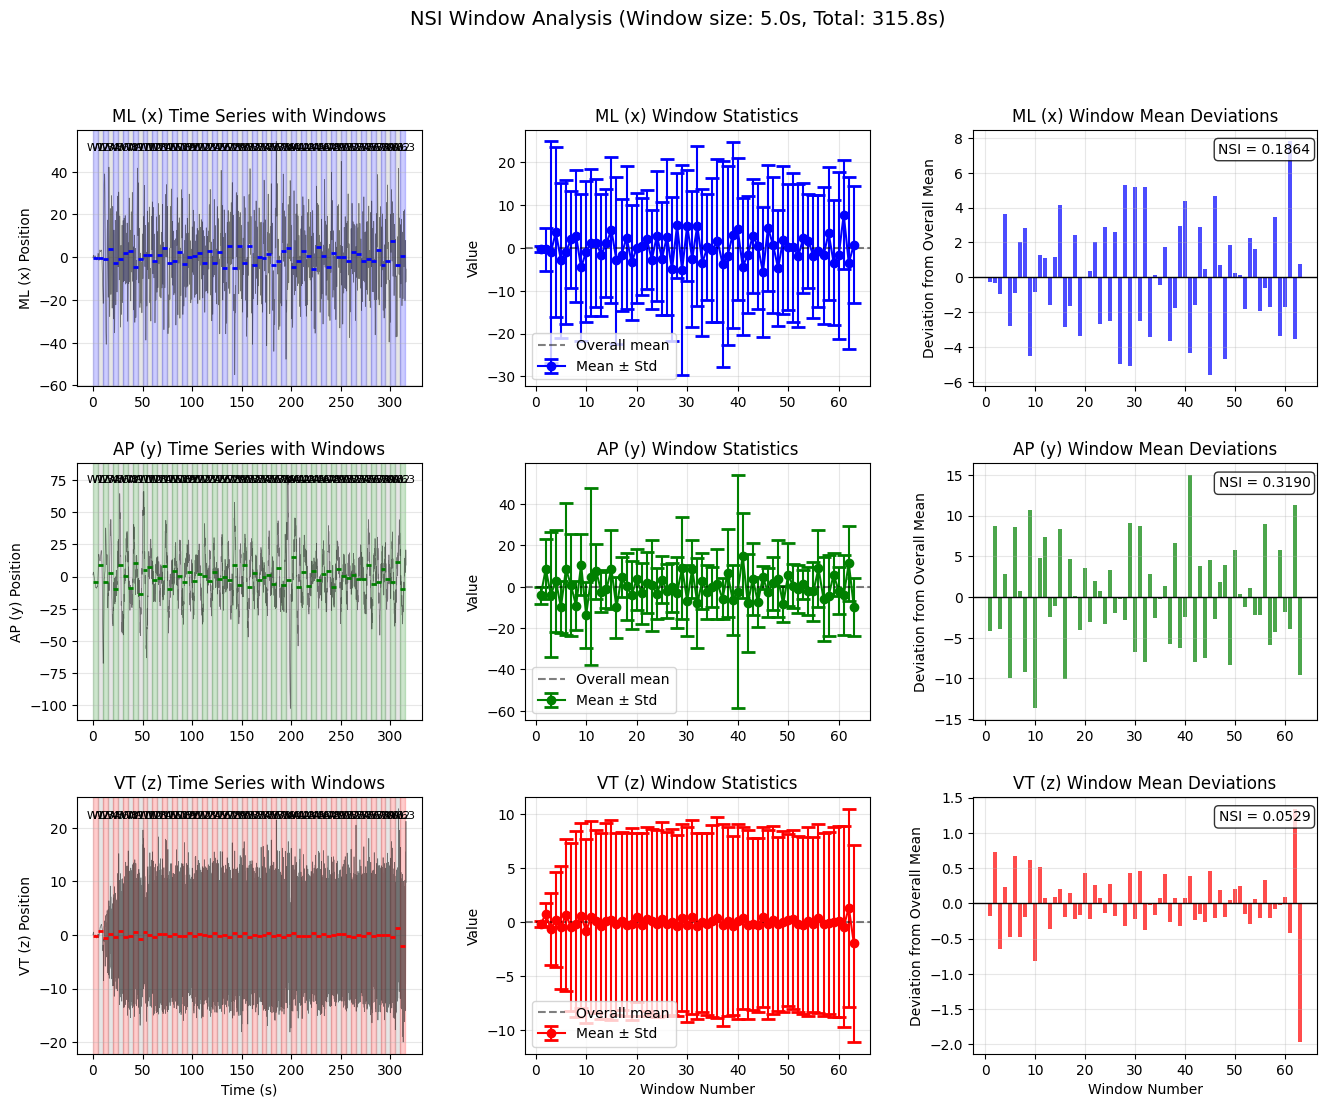

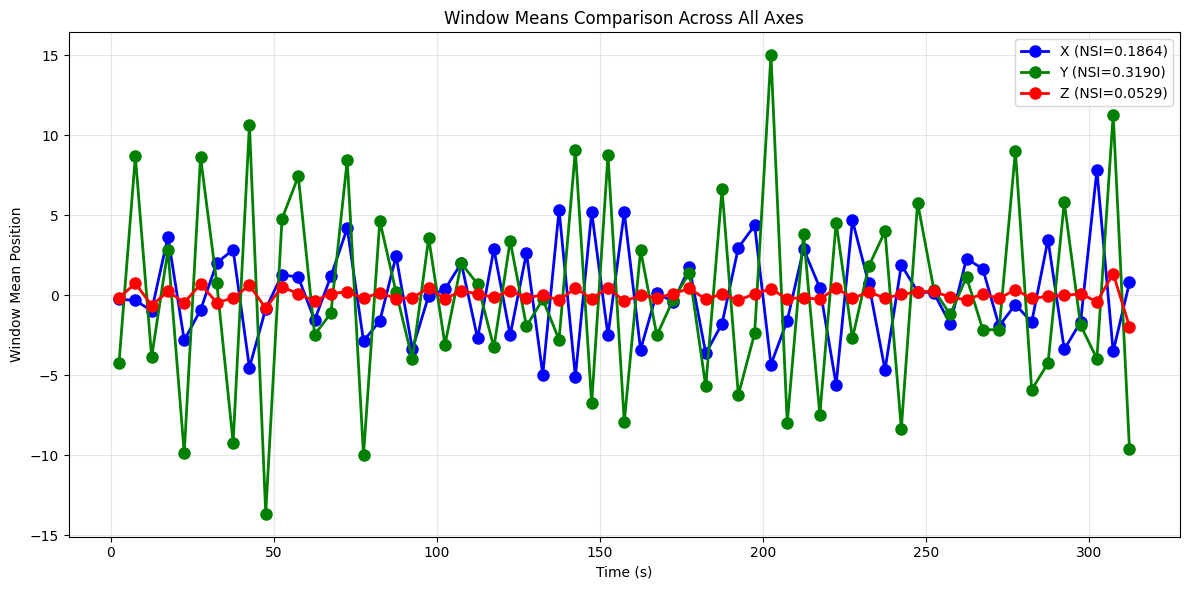

Spatial NSI: {np.str_('x'): np.float64(0.18642517273796622), np.str_('y'): np.float64(0.3189828631023251), np.str_('z'): np.float64(0.05291235528840779)}

SUMMARY
Temporal NSI: 0.3271
Spatial NSI:
  x: 0.1864
  y: 0.3190
  z: 0.0529


In [8]:
import pandas as pd
import xarray as xr
from pathlib import Path

# Add the functions from your paste.txt file here
# (I'm assuming they're imported or defined elsewhere)

def main():
    # Set up paths
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())
    
    # Fix path - using correct file for markers
    data_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "08" / "markers.nc"
    
    # Fix path - using correct file for events (should be .csv, not .nc)
    events_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "08" / "events.csv"  # Changed from markers.nc
    
    try:
        # Load markers data
        ds = xr.open_dataarray(data_path)
        print("Markers DataArray loaded with shape:", ds.shape)
        print("Markers dimensions:", ds.dims)
        print("Markers coordinates:", list(ds.coords.keys()))
        
        # Load events data
        df_events = pd.read_csv(events_path)
        print("Events DataFrame loaded with shape:", df_events.shape)
        print("Events columns:", df_events.columns.tolist())
        
        # Filter events by time range
        t_max = df_events['time'].max()
        trim = 30.0
        df_events_filtered = df_events[(df_events['time'] >= trim) & (df_events['time'] <= 125.0)]
        print(f"Events DataFrame filtered to time range: {df_events_filtered['time'].min():.2f} to {df_events_filtered['time'].max():.2f}")
        
        # Count foot strikes
        foot_strikes = df_events_filtered[df_events_filtered['label'] == 'Foot Strike']
        print("Number of foot strikes:", len(foot_strikes))
        
        # Compute temporal NSI
        nsi_temporal = compute_temporal_nsi_from_events(
            df_events_filtered, 
            strides_per_window=20, 
            trim_strides=20,  # Added missing parameter
            outlier_thresh=3.0
        )
        print("Temporal NSI:", nsi_temporal)
        
        # Preprocess markers data before computing spatial NSI
        # Apply preprocessing to the markers data
        markers_preprocessed = preprocess_signal(
            ds, 
            fs=100.0, 
            poly_order=1, 
            hp_cutoff=0.1,  # High-pass filter at 0.1 Hz as mentioned in spatial NSI function
            lp_cutoff=None,
            filter_order=4
        )
        
        # Convert back to xarray for spatial NSI computation
        ds_preprocessed = xr.DataArray(
            markers_preprocessed,
            coords=ds.coords,
            dims=ds.dims
        )
        
        # Compute spatial NSI
        nsi_spatial, nsi_details = compute_spatial_nsi(
            ds_preprocessed, 
            window_samples=500, 
            fs=100.0
        )
        print("Spatial NSI:", nsi_spatial)
        
        # Print summary
        print("\n" + "="*50)
        print("SUMMARY")
        print("="*50)
        print(f"Temporal NSI: {nsi_temporal:.4f}")
        print("Spatial NSI:")
        for axis, value in nsi_spatial.items():
            print(f"  {axis}: {value:.4f}")
            
    except FileNotFoundError as e:
        print(f"File not found: {e}")
        print("Please check that the file paths are correct.")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

# Patient 09

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Markers DataArray loaded with shape: (3, 125, 24312)
Markers dimensions: ('axis', 'channel', 'time')
Markers coordinates: ['axis', 'channel', 'time']
Events DataFrame loaded with shape: (1128, 4)
Events columns: ['time', 'label', 'context', 'icon_id']
Events DataFrame filtered to time range: 30.26 to 124.91
Number of foot strikes: 221
Temporal NSI: 0.49032156400335175


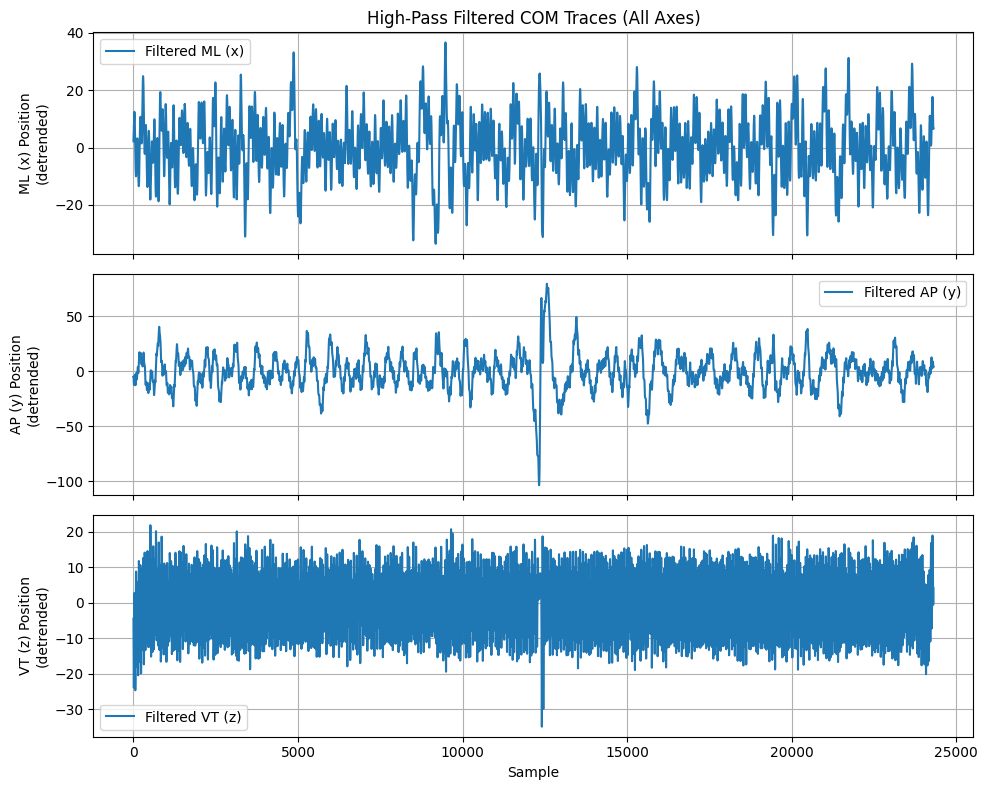

COM series length: 24312 samples (243.12 s)
Window size:       500 samples (5.00 s)
Number of windows: 48
--------------------------------------------------------------------------------

Axis: x
Overall NSI: 0.2477
Window          Time Range (s)       Mean         Std         
------------------------------------------------------------
Window 1          0.00 -   5.00 s      1.8853      9.3764
Window 2          5.00 -  10.00 s      0.0115     10.5072
Window 3         10.00 -  15.00 s     -1.0902      8.9095
Window 4         15.00 -  20.00 s     -1.7674      9.1788
Window 5         20.00 -  25.00 s      3.1907     10.4822
Window 6         25.00 -  30.00 s     -0.6196      9.9468
Window 7         30.00 -  35.00 s     -4.1119     12.6166
Window 8         35.00 -  40.00 s      4.0138      7.6101
Window 9         40.00 -  45.00 s     -2.3596      8.5689
Window 10        45.00 -  50.00 s      5.0496     12.6869
Window 11        50.00 -  55.00 s     -4.4508     10.9188
Window 12        55.00

C:\Users\Natascha\AppData\Local\Temp\ipykernel_9412\290132175.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


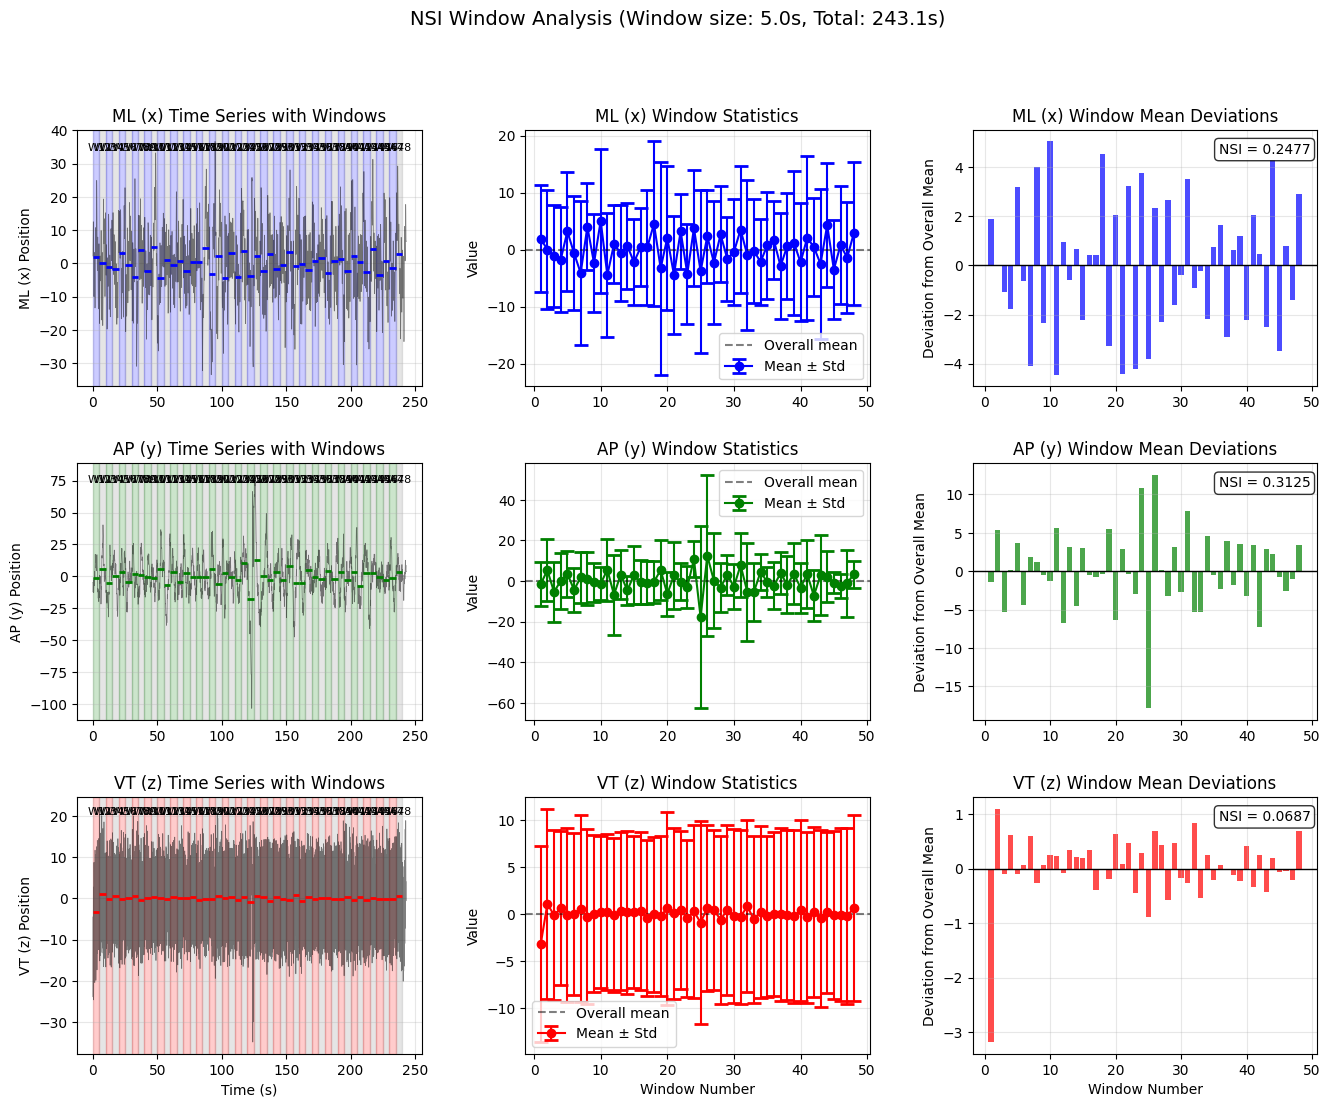

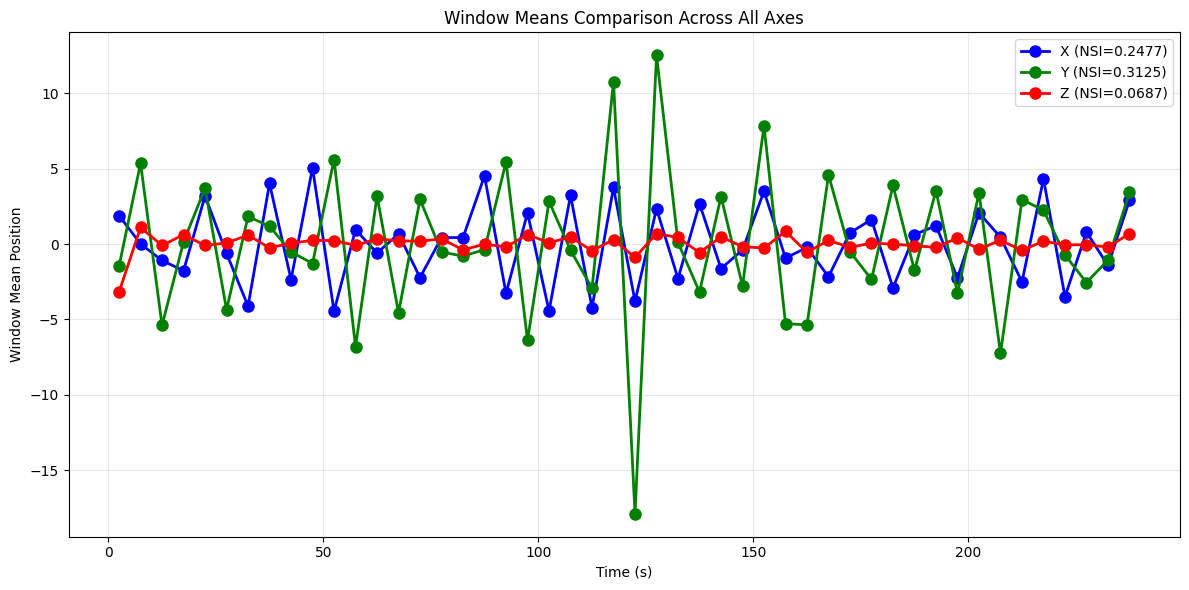

Spatial NSI: {np.str_('x'): np.float64(0.24767374992751606), np.str_('y'): np.float64(0.3125389732571922), np.str_('z'): np.float64(0.06871617285691232)}

SUMMARY
Temporal NSI: 0.4903
Spatial NSI:
  x: 0.2477
  y: 0.3125
  z: 0.0687


In [ ]:
import pandas as pd
import xarray as xr
from pathlib import Path


def main():
    # Set up paths
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())
    
    # Fix path - using correct file for markers
    data_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "09" / "markers.nc"
    
    # Fix path - using correct file for events (should be .csv, not .nc)
    events_path = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "09" / "events.csv"  # Changed from markers.nc
    
    try:
        # Load markers data
        ds = xr.open_dataarray(data_path)
        print("Markers DataArray loaded with shape:", ds.shape)
        print("Markers dimensions:", ds.dims)
        print("Markers coordinates:", list(ds.coords.keys()))
        
        # Load events data
        df_events = pd.read_csv(events_path)
        print("Events DataFrame loaded with shape:", df_events.shape)
        print("Events columns:", df_events.columns.tolist())
        
        # Filter events by time range
        t_max = df_events['time'].max()
        trim = 30.0
        df_events_filtered = df_events[(df_events['time'] >= trim) & (df_events['time'] <= 125.0)]
        print(f"Events DataFrame filtered to time range: {df_events_filtered['time'].min():.2f} to {df_events_filtered['time'].max():.2f}")
        
        # Count foot strikes
        foot_strikes = df_events_filtered[df_events_filtered['label'] == 'Foot Strike']
        print("Number of foot strikes:", len(foot_strikes))
        
        # Compute temporal NSI
        nsi_temporal = compute_temporal_nsi_from_events(
            df_events_filtered, 
            strides_per_window=20, 
            trim_strides=20,  # Added missing parameter
            outlier_thresh=3.0
        )
        print("Temporal NSI:", nsi_temporal)
        
        # Preprocess markers data before computing spatial NSI
        # Apply preprocessing to the markers data
        markers_preprocessed = preprocess_signal(
            ds, 
            fs=100.0, 
            poly_order=1, 
            hp_cutoff=0.1,  # High-pass filter at 0.1 Hz as mentioned in spatial NSI function
            lp_cutoff=None,
            filter_order=4
        )
        
        # Convert back to xarray for spatial NSI computation
        ds_preprocessed = xr.DataArray(
            markers_preprocessed,
            coords=ds.coords,
            dims=ds.dims
        )
        
        # Compute spatial NSI
        nsi_spatial, nsi_details = compute_spatial_nsi(
            ds_preprocessed, 
            window_samples=500, 
            fs=100.0
        )
        print("Spatial NSI:", nsi_spatial)
        
        # Print summary
        print("\n" + "="*50)
        print("SUMMARY")
        print("="*50)
        print(f"Temporal NSI: {nsi_temporal:.4f}")
        print("Spatial NSI:")
        for axis, value in nsi_spatial.items():
            print(f"  {axis}: {value:.4f}")
            
    except FileNotFoundError as e:
        print(f"File not found: {e}")
        print("Please check that the file paths are correct.")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()